In [ ]:
# ============================================================
# GRAPH 1: OVERALL PRICE DISTRIBUTION
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Basic statistical summary

df=pd.read_excel(r"csv_Final_Bosss.xlsx")
print("PRICE SUMMARY")
print(df["Price"].describe())


# 2. Important percentiles
print("\nPRICE PERCENTILES")
print(df["Price"].quantile([0.50, 0.75, 0.90, 0.95, 0.99]))


# 3. Plot price distribution
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Price",
    bins=40
)

plt.xlabel("Mission Price ($ million)")
plt.ylabel("Number of Missions")
plt.title("Distribution of Mission Prices")

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# SPACE MISSION PRICE ANALYSIS - 5 GRAPHS
# ============================================================


# ============================================================
# GRAPH 1: OVERALL PRICE DISTRIBUTION
# ============================================================

print("PRICE SUMMARY")
print(df["Price"].describe())

print("\nPRICE PERCENTILES")
print(df["Price"].quantile([0.50, 0.75, 0.90, 0.95, 0.99]))

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Price",
    bins=40
)

plt.xlabel("Mission Price ($ million)")
plt.ylabel("Number of Missions")
plt.title("Distribution of Mission Prices")

plt.show()


# ============================================================
# GRAPH 2: PRICE VS DECADE
# ============================================================

decade_summary = df.groupby("Decade").agg(
    Missions=("Price", "count"),
    Median_Price=("Price", "median"),
    Mean_Price=("Price", "mean")
)

print("\nPRICE BY DECADE")
print(decade_summary)

plt.figure(figsize=(10, 5))

plt.plot(
    decade_summary.index,
    decade_summary["Median_Price"],
    marker="o",
    label="Median"
)

plt.plot(
    decade_summary.index,
    decade_summary["Mean_Price"],
    marker="o",
    label="Mean"
)

plt.xlabel("Decade")
plt.ylabel("Mission Price ($ million)")
plt.title("Mean vs Median Mission Price Across Decades")

plt.xticks(decade_summary.index)
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# GRAPH 3: ORGANISATION - COST VS VOLUME
# ============================================================

org_summary = df.groupby("Organisation").agg(
    Missions=("Price", "count"),
    Median_Price=("Price", "median"),
    Mean_Price=("Price", "mean"),
    Std_Price=("Price", "std")
)

# Keep organisations with at least 10 missions
org_summary = org_summary[
    org_summary["Missions"] >= 10
]

print("\nORGANISATION COST-VOLUME ANALYSIS")
print(org_summary.sort_values("Median_Price", ascending=False))


plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=org_summary,
    x="Median_Price",
    y="Missions",
    size="Missions",
    legend=False
)

plt.xlabel("Median Mission Price ($ million)")
plt.ylabel("Number of Missions")
plt.title("Mission Volume vs Typical Mission Cost")

plt.grid(True)

plt.show()


# ============================================================
# GRAPH 4: PRICE VS MISSION OUTCOME
# ============================================================

print("\nMISSION STATUS COUNTS")
print(df["Mission_Status"].value_counts())

status_summary = df.groupby("Mission_Status").agg(
    Missions=("Price", "count"),
    Median_Price=("Price", "median"),
    Mean_Price=("Price", "mean")
)

print("\nPRICE BY MISSION STATUS")
print(status_summary)


plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Mission_Status",
    y="Price"
)

plt.xlabel("Mission Status")
plt.ylabel("Mission Price ($ million)")
plt.title("Mission Price Distribution by Mission Outcome")

plt.xticks(rotation=20)

plt.show()


# ============================================================
# GRAPH 5: COST × VOLUME × SUCCESS
# ============================================================

period_summary = df.groupby("Decade").agg(
    Missions=("Price", "count"),
    Median_Price=("Price", "median"),
    Mean_Price=("Price", "mean")
)

# Calculate successful missions
success_count = df[df["Mission_Status"] == "Success"].groupby("Decade").size()

period_summary["Success_Rate"] = (
    success_count / period_summary["Missions"] * 100
)

period_summary["Success_Rate"] = period_summary["Success_Rate"].fillna(0)

print("\nDECADE COST-VOLUME-SUCCESS ANALYSIS")
print(period_summary)


# Bubble/scatter-style analysis
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=period_summary,
    x="Median_Price",
    y="Missions",
    size="Success_Rate",
    sizes=(50, 500),
    legend=True
)

plt.xlabel("Median Mission Price ($ million)")
plt.ylabel("Number of Missions")
plt.title("Mission Cost, Volume and Success Across Decades")

plt.grid(True)

plt.show()

“The objective of this analysis is to study historical space mission data and identify patterns in mission costs, mission frequency, organisational performance, and mission outcomes. The aim is to understand how mission costs have varied over time and across organisations, and whether cost appears to be associated with mission success.”

The first major observation is that mission prices are highly uneven. The median mission cost is around $200 million, whereas the mean is around $2.13 billion. This large difference indicates that high-cost observations are strongly affecting the average. Therefore, the median gives us a better picture of the typical mission cost.

However, I also observed a very large concentration of values at exactly $5 billion. So before drawing a strong financial conclusion, I need to investigate whether these values represent actual mission costs or values introduced during the missing-value treatment

The decade-wise analysis shows that mission prices were considerably higher in the 1960s, 1970s and 1980s, while the median price drops sharply from the 1990s onwards. This suggests a major change in the recorded cost profile of space missions over time.
But because the $5 billion value is heavily concentrated in some periods, I don't want to interpret this directly as proof that space missions became cheaper. I need to investigate the composition of those values first.

In [ ]:
# ============================================================
# GRAPH 1: OVERALL PRICE DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Price summary
print("PRICE SUMMARY")
print(df["Price"].describe())

print("\nPRICE PERCENTILES")
print(df["Price"].quantile([0.50, 0.75, 0.90, 0.95, 0.99]))

# Graph
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Price",
    bins=40
)

plt.xlabel("Mission Price ($ million)")
plt.ylabel("Number of Missions")
plt.title("Distribution of Mission Prices")

plt.show()


# ============================================================
# INTERPRETATION
# ============================================================

print("\n" + "="*70)
print("PROBLEM STATEMENT")
print("="*70)

print("""
What does the overall financial distribution of space mission
costs look like, and is the mean or median a better representation
of a typical mission cost?
""")


print("\n" + "="*70)
print("ANALYSIS")
print("="*70)

print("""
The price distribution is highly uneven. The median mission cost
is around $200 million, while the mean is approximately $2.13 billion.
There is also a very large concentration of observations at exactly
$5 billion.

This indicates that high-value observations are strongly influencing
the mean and that the median provides a more representative view of
the typical mission cost.
""")


print("\n" + "="*70)
print("ANSWER / INFERENCE")
print("="*70)

print("""
The median is a more suitable measure of typical mission cost than
the mean because the distribution is heavily influenced by extremely
high values. However, the large concentration at exactly $5 billion
needs further investigation before making strong financial conclusions.
""")

In [ ]:
# ============================================================
# GRAPH 2: PRICE VS DECADE
# ============================================================

decade_summary = df.groupby("Decade").agg(
    Missions=("Price", "count"),
    Median_Price=("Price", "median"),
    Mean_Price=("Price", "mean")
)

print("PRICE BY DECADE")
print(decade_summary)


# Graph
plt.figure(figsize=(10, 5))

plt.plot(
    decade_summary.index,
    decade_summary["Median_Price"],
    marker="o",
    label="Median"
)

plt.plot(
    decade_summary.index,
    decade_summary["Mean_Price"],
    marker="o",
    label="Mean"
)

plt.xlabel("Decade")
plt.ylabel("Mission Price ($ million)")
plt.title("Mean vs Median Mission Price Across Decades")

plt.xticks(decade_summary.index)
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# INTERPRETATION
# ============================================================

print("\n" + "="*70)
print("PROBLEM STATEMENT")
print("="*70)

print("""
How has the typical cost of space missions changed across
different decades?
""")


print("\n" + "="*70)
print("ANALYSIS")
print("="*70)

print("""
The decade-wise analysis shows substantially higher recorded
mission costs during the 1960s, 1970s and 1980s.

From the 1990s onward, the median mission price drops sharply
and remains considerably lower during the 2000s, 2010s and 2020s.

The mean is generally higher than the median, indicating that
high-priced missions continue to influence the average.
""")


print("\n" + "="*70)
print("ANSWER / INFERENCE")
print("="*70)

print("""
The data indicates a major change in the recorded mission-cost
profile over time, with typical mission costs appearing much lower
in the later decades.

However, this should not immediately be interpreted as proof that
space missions became cheaper, because the large concentration of
$5 billion values may be influencing the historical pattern.
Further investigation of these values is required.
""")

In [ ]:
# ============================================================
# GRAPH 3: ORGANISATION - COST VS VOLUME
# ============================================================

org_summary = df.groupby("Organisation").agg(
    Missions=("Price", "count"),
    Median_Price=("Price", "median"),
    Mean_Price=("Price", "mean"),
    Std_Price=("Price", "std")
)

# Keep organisations with at least 10 missions
org_summary = org_summary[
    org_summary["Missions"] >= 10
]

print("ORGANISATION COST-VOLUME ANALYSIS")
print(org_summary.sort_values("Median_Price", ascending=False))


# Graph
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=org_summary,
    x="Median_Price",
    y="Missions",
    size="Missions",
    legend=False
)

plt.xlabel("Median Mission Price ($ million)")
plt.ylabel("Number of Missions")
plt.title("Mission Volume vs Typical Mission Cost")

plt.grid(True)

plt.show()


# ============================================================
# INTERPRETATION
# ============================================================

print("\n" + "="*70)
print("PROBLEM STATEMENT")
print("="*70)

print("""
Do different organisations show different cost-volume profiles,
and are there organisations that combine relatively low typical
mission costs with high mission volume?
""")


print("\n" + "="*70)
print("ANALYSIS")
print("="*70)

print("""
The analysis shows substantial differences in mission volume
across organisations.

Most organisations are concentrated in the lower-volume region,
while a small number of organisations have conducted significantly
more missions.

Comparing mission volume with median price allows us to investigate
whether high operational activity is associated with relatively
lower typical mission costs.
""")


print("\n" + "="*70)
print("ANSWER / INFERENCE")
print("="*70)

print("""
The data reveals clear differences in organisational mission volume
and provides a useful cost-volume comparison.

However, high mission volume alone cannot be considered proof of
cost efficiency or profitability. Mission type, complexity, payload,
and organisational objectives would also need to be considered.
""")

In [ ]:
# ============================================================
# GRAPH 4: PRICE VS MISSION OUTCOME
# ============================================================

print("MISSION STATUS COUNTS")
print(df["Mission_Status"].value_counts())


status_summary = df.groupby("Mission_Status").agg(
    Missions=("Price", "count"),
    Median_Price=("Price", "median"),
    Mean_Price=("Price", "mean")
)

print("\nPRICE BY MISSION STATUS")
print(status_summary)


# Graph
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Mission_Status",
    y="Price"
)

plt.xlabel("Mission Status")
plt.ylabel("Mission Price ($ million)")
plt.title("Mission Price Distribution by Mission Outcome")

plt.xticks(rotation=20)

plt.show()


# ============================================================
# PRICE BAND ANALYSIS
# ============================================================

df["Price_Band"] = pd.qcut(
    df["Price"],
    q=4,
    duplicates="drop"
)

success_by_price = pd.crosstab(
    df["Price_Band"],
    df["Mission_Status"],
    normalize="index"
) * 100

print("\nMISSION OUTCOME PERCENTAGE BY PRICE BAND")
print(success_by_price.round(2))


# ============================================================
# INTERPRETATION
# ============================================================

print("\n" + "="*70)
print("PROBLEM STATEMENT")
print("="*70)

print("""
Is higher mission expenditure associated with different
mission outcomes?
""")


print("\n" + "="*70)
print("ANALYSIS")
print("="*70)

print("""
The mission-status comparison examines the median, mean and
distribution of mission prices across different outcomes.

The price-band analysis additionally compares the percentage
distribution of mission outcomes across different cost groups.

This allows us to determine whether mission outcomes appear to
change as mission cost increases.
""")


print("\n" + "="*70)
print("ANSWER / INFERENCE")
print("="*70)

print("""
FINAL INFERENCE TO BE COMPLETED AFTER OBSERVING THE RESULT:

Compare the success rate and price distribution across the
different price bands.

If higher-priced groups show higher success rates, this suggests
an association between higher expenditure and mission success.

If the success rates are similar across price groups, then higher
spending does not show a clear advantage in this dataset.

This represents association, not causation.
""")


ORIGINAL PRICE AVAILABILITY
Total missions       : 4,324
Originally known     : 964
Originally missing   : 3,360

IMPUTATION COVERAGE
Original missing values : 3,360
Team method filled      : 3,360
Real-world benchmark   : 3,339
Still unresolved       : 21
Benchmark coverage     : 99.38%

ORGANISATION-WISE IMPUTATION COMPARISON
                  Team_Imputation  Real_World_Benchmark  Missing_Missions
Organisation                                                             
RVSN USSR                  5000.0                 27.00              1775
General Dynamics             62.0                 85.00               251
Arianespace                 200.0                107.29               183
VKS RF                       41.8                 90.00               168
US Air Force                 59.0                350.00               135
Boeing                      164.0                137.00               129
Martin Marietta              35.0                225.00               105
CAS

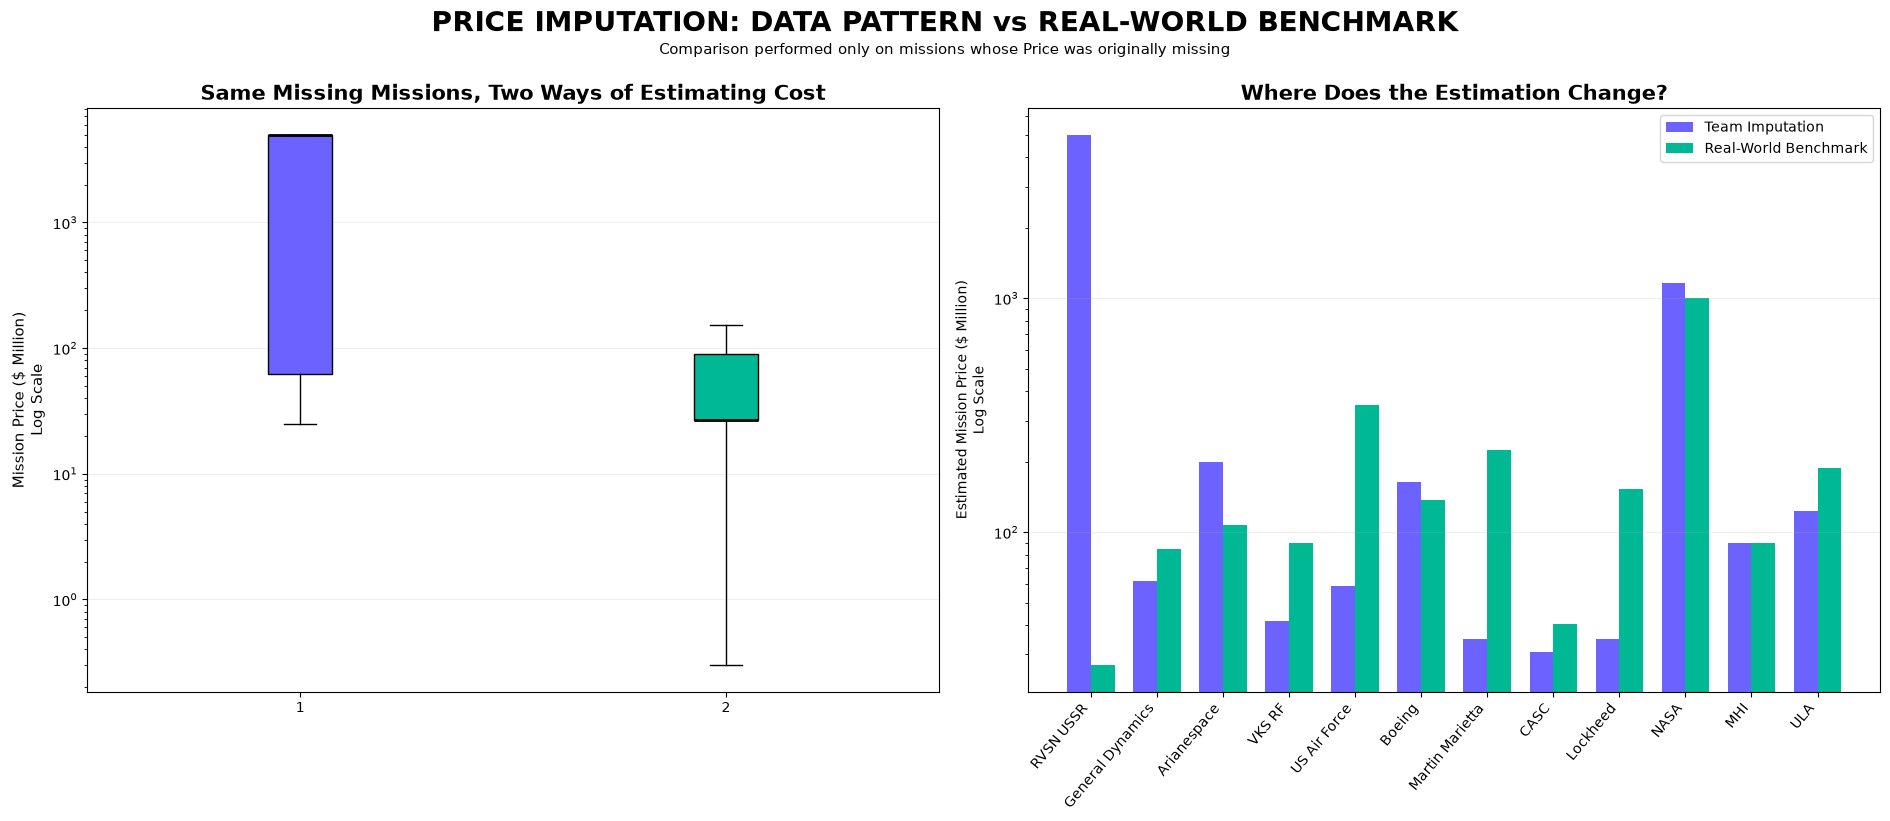


OVERALL COMPARISON
Team method median       : $5,000.00M
Real-world median        : $27.00M

Team method mean         : $2,713.89M
Real-world mean          : $86.45M

Median absolute difference: $4,973.00M
Mean absolute difference  : $2,680.41M

BIGGEST METHOD DISAGREEMENTS
Organisation
RVSN USSR          4973.00
US Air Force        291.00
Martin Marietta     180.32
NASA                178.71
Lockheed            118.00
Arianespace          92.71
ESA                  70.29
ULA                  64.40
Exos                 61.70
OneSpace             58.90
Name: Absolute_Difference, dtype: float64


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# FILES
# ============================================================

original_file = r"orignal.csv"

# YOUR EXISTING TEAM-IMPUTED FILE
old_imputed_file = r"Space_Mission_Data_Final.csv"

# REAL-WORLD BENCHMARK FILE
real_world_file = r"Space_Mission_Data_RealWorld_Imputed.csv"


# ============================================================
# LOAD
# ============================================================

original = pd.read_csv(original_file)
old = pd.read_csv(old_imputed_file)
real = pd.read_csv(real_world_file)


# ============================================================
# CLEAN PRICE
# ============================================================

def clean_price(series):

    return pd.to_numeric(
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.strip(),
        errors="coerce"
    )


original["Price"] = clean_price(original["Price"])
old["Price"] = clean_price(old["Price"])
real["Price"] = clean_price(real["Price"])


# ============================================================
# SAFETY CHECK
# ============================================================

assert len(original) == len(old) == len(real), \
    "ERROR: Dataset row counts do not match."


# ============================================================
# IDENTIFY ORIGINAL MISSING VALUES
# ============================================================

original_missing = original["Price"].isna()


print("\n" + "=" * 75)
print("ORIGINAL PRICE AVAILABILITY")
print("=" * 75)

print(f"Total missions       : {len(original):,}")
print(f"Originally known     : {original['Price'].notna().sum():,}")
print(f"Originally missing   : {original_missing.sum():,}")


# ============================================================
# COMPARE ONLY ORIGINAL NULL VALUES
# ============================================================

comparison = pd.DataFrame({

    "Organisation":
        original.loc[
            original_missing,
            "Organisation"
        ].values,

    "Team_Imputation":
        old.loc[
            original_missing,
            "Price"
        ].values,

    "Real_World_Benchmark":
        real.loc[
            original_missing,
            "Price"
        ].values
})


# ============================================================
# COVERAGE
# ============================================================

team_available = (
    comparison["Team_Imputation"].notna().sum()
)

real_available = (
    comparison["Real_World_Benchmark"].notna().sum()
)

real_unresolved = (
    comparison["Real_World_Benchmark"].isna().sum()
)


print("\n" + "=" * 75)
print("IMPUTATION COVERAGE")
print("=" * 75)

print(
    f"Original missing values : {len(comparison):,}"
)

print(
    f"Team method filled      : {team_available:,}"
)

print(
    f"Real-world benchmark   : {real_available:,}"
)

print(
    f"Still unresolved       : {real_unresolved:,}"
)

print(
    f"Benchmark coverage     : "
    f"{real_available / len(comparison) * 100:.2f}%"
)


# ============================================================
# KEEP ONLY ROWS WHERE BOTH METHODS EXIST
# ============================================================

comparison_clean = comparison.dropna(
    subset=[
        "Team_Imputation",
        "Real_World_Benchmark"
    ]
).copy()


# ============================================================
# DIFFERENCE BETWEEN METHODS
# ============================================================

comparison_clean["Absolute_Difference"] = (
    comparison_clean["Team_Imputation"]
    - comparison_clean["Real_World_Benchmark"]
).abs()


comparison_clean["Difference_%"] = (
    comparison_clean["Absolute_Difference"]
    /
    comparison_clean["Real_World_Benchmark"]
    * 100
)


# ============================================================
# ORGANISATION LEVEL
# ============================================================

org_comparison = (
    comparison_clean
    .groupby("Organisation")
    .agg(

        Team_Imputation=(
            "Team_Imputation",
            "median"
        ),

        Real_World_Benchmark=(
            "Real_World_Benchmark",
            "first"
        ),

        Missing_Missions=(
            "Team_Imputation",
            "count"
        )
    )
)


# ============================================================
# FIND ORGANISATIONS WITH MOST MISSING VALUES
# ============================================================

org_comparison = (
    org_comparison
    .sort_values(
        "Missing_Missions",
        ascending=False
    )
)


# Top 12
plot_data = org_comparison.head(12).copy()


# ============================================================
# PRINT ORGANISATION COMPARISON
# ============================================================

print("\n" + "=" * 90)
print("ORGANISATION-WISE IMPUTATION COMPARISON")
print("=" * 90)

print(
    plot_data.round(2)
)


# ============================================================
# CINEMATIC TWO-PANEL GRAPH
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(19, 8)
)


# ============================================================
# PANEL 1
# DISTRIBUTION
# ============================================================

box_data = [
    comparison_clean["Team_Imputation"],
    comparison_clean["Real_World_Benchmark"]
]

bp = axes[0].boxplot(
    box_data,
    label=[
        "Team\nImputation",
        "Real-World\nBenchmark"
    ],
    patch_artist=True,
    showfliers=False
)


# Custom colours
bp["boxes"][0].set_facecolor("#6C63FF")
bp["boxes"][1].set_facecolor("#00B894")

for median in bp["medians"]:
    median.set_color("black")
    median.set_linewidth(2)


axes[0].set_yscale("log")

axes[0].set_ylabel(
    "Mission Price ($ Million)\nLog Scale",
    fontsize=11
)

axes[0].set_title(
    "Same Missing Missions, Two Ways of Estimating Cost",
    fontsize=15,
    fontweight="bold"
)

axes[0].grid(
    axis="y",
    alpha=0.20
)


# ============================================================
# PANEL 2
# ORGANISATION COMPARISON
# ============================================================

x = np.arange(
    len(plot_data)
)

width = 0.36


bars1 = axes[1].bar(
    x - width/2,
    plot_data["Team_Imputation"],
    width,
    label="Team Imputation",
    color="#6C63FF"
)


bars2 = axes[1].bar(
    x + width/2,
    plot_data["Real_World_Benchmark"],
    width,
    label="Real-World Benchmark",
    color="#00B894"
)


axes[1].set_yscale("log")

axes[1].set_xticks(x)

axes[1].set_xticklabels(
    plot_data.index,
    rotation=50,
    ha="right"
)

axes[1].set_ylabel(
    "Estimated Mission Price ($ Million)\nLog Scale"
)

axes[1].set_title(
    "Where Does the Estimation Change?",
    fontsize=15,
    fontweight="bold"
)

axes[1].legend()

axes[1].grid(
    axis="y",
    alpha=0.20
)


# ============================================================
# MAIN TITLE
# ============================================================

fig.suptitle(
    "PRICE IMPUTATION: DATA PATTERN vs REAL-WORLD BENCHMARK",
    fontsize=20,
    fontweight="bold",
    y=1.02
)


fig.text(
    0.5,
    0.965,
    "Comparison performed only on missions whose Price was originally missing",
    ha="center",
    fontsize=11
)


plt.tight_layout()

plt.show()


# ============================================================
# FINAL STATISTICS
# ============================================================

print("\n" + "=" * 75)
print("OVERALL COMPARISON")
print("=" * 75)

print(
    f"Team method median       : "
    f"${comparison_clean['Team_Imputation'].median():,.2f}M"
)

print(
    f"Real-world median        : "
    f"${comparison_clean['Real_World_Benchmark'].median():,.2f}M"
)

print(
    f"\nTeam method mean         : "
    f"${comparison_clean['Team_Imputation'].mean():,.2f}M"
)

print(
    f"Real-world mean          : "
    f"${comparison_clean['Real_World_Benchmark'].mean():,.2f}M"
)

print(
    f"\nMedian absolute difference: "
    f"${comparison_clean['Absolute_Difference'].median():,.2f}M"
)

print(
    f"Mean absolute difference  : "
    f"${comparison_clean['Absolute_Difference'].mean():,.2f}M"
)


# ============================================================
# BIGGEST DISAGREEMENTS
# ============================================================

biggest = (
    comparison_clean
    .groupby("Organisation")
    ["Absolute_Difference"]
    .mean()
    .sort_values(
        ascending=False
    )
    .head(10)
)


print("\n" + "=" * 75)
print("BIGGEST METHOD DISAGREEMENTS")
print("=" * 75)

print(
    biggest.round(2)
)

###  Price Analysis — Key Insight

- **Problem:** Large number of missing Price values.
- **Handling:** Organisation Median → Decade Median → Overall Median.
- **Investigation:** Imputation created a strong **$5B concentration**, mainly from RVSN USSR.
- **Validation:** Compared dataset-based estimates with **real-world cost benchmarks**.
- **Finding:** Results vary significantly by imputation method.
- **Conclusion:** **Observed prices are most reliable; imputed prices are estimates and must be interpreted with caution.**